In [1]:
import os, pickle, joblib, numpy as np, pandas as pd
from pathlib import Path
from lifelines import KaplanMeierFitter
from scipy.cluster.hierarchy import fcluster
from numpy import trapz
import matplotlib.pyplot as plt
from sksurv.metrics import cumulative_dynamic_auc
from matplotlib.backends.backend_pdf import PdfPages

In [ ]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [2]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

def make_time_grid(y_time, y_event, q=0.95, m=300):
    y_time = np.asarray(y_time)
    y_event = np.asarray(y_event).astype(bool)
    evt = y_time[y_event]
    tau = float(np.quantile(evt, q)) if evt.size > 0 else float(y_time.max())
    t = np.linspace(0.0, tau, m)
    return t, tau

def km_curve_by_mask(dur, evt, t):
    kmf = KaplanMeierFitter()
    kmf.fit(np.asarray(dur), np.asarray(evt).astype(bool))
    return kmf.survival_function_at_times(t).values

def plot_overlay_cluster(t, S_km, S_pr, title, savepath=None, show=True):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.step(t, S_km, where="post", label="K-M", linewidth=2)
    plt.plot(t, S_pr, linestyle="--", label="RSF pred (mean)", linewidth=2)
    plt.xlabel("Time (days)"); plt.ylabel("Survival probability")
    plt.title(title); plt.legend(); plt.tight_layout()
    if savepath:
        # 확장자를 pdf로 강제
        savepath = Path(savepath).with_suffix(".pdf")
        plt.savefig(savepath, format="pdf", bbox_inches="tight")  # dpi 불필요(벡터)
    if show:
        plt.show()
    plt.close()

# def plot_overlay_cluster(t, S_km, S_pr, title, savepath=None, show=True):
#     plt.figure(figsize=(6,4))
#     plt.step(t, S_km, where="post", label="KM", linewidth=2)
#     plt.plot(t, S_pr, linestyle="--", label="RSF pred (mean)", linewidth=2)
#     plt.xlabel("Time (days)")
#     plt.ylabel("Survival probability")
#     plt.ylim(0.0, 1.0)                               # <<< 고정
#     plt.yticks(np.linspace(0, 1, 6))                 # 0,0.2,...,1.0
#     plt.title(title)
#     plt.legend()
#     plt.tight_layout()
#     if savepath:
#         savepath = Path(savepath).with_suffix(".pdf")
#         plt.savefig(savepath, format="pdf", bbox_inches="tight")
#     if show:
#         plt.show()
#     plt.close()


In [3]:
## Configs
SEED = 64
base1 = '/media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp'

srv = f'{base}/survModel'
colmap = f'{base}/Clustering/M13'
# ipt = f'{base}/Dataset'
ipt = f'{base}/withPCA/PCA30/'
# ipt_dir = f'{ipt}/C8_Sil-Opt'
ipt_dir = f'{ipt}/C27'

In [33]:
df = pd.read_csv(os.path.join(ipt_dir, 'KNN_df_combined.csv'))
df.set_index('idx_code', inplace=True)
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,11
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,17
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,3
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,24
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,11
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,18
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,9


In [34]:
TIME_COL  = "stday"         # 생존시간 컬럼
EVENT_COL = "death_label"   # 사건(1=사망) 컬럼

Z_PATH   = f"{ipt}/Z_objects.pkl"
RSF_PATH = f"{srv}/models/rsf_M01.pkl"

OUT = Path(ipt_dir) / "Validate_HierC_vs_RSF"
OUT.mkdir(parents=True, exist_ok=True)

USE_EXISTING_CLUSTER_LABELS = "Cluster_Labels" in df.columns
K_LIST = [23, 24, 25, 26, 27]
print("[2] OUT:", OUT)
print("[2] USE_EXISTING_CLUSTER_LABELS:", USE_EXISTING_CLUSTER_LABELS, "| K_LIST:", K_LIST)

[2] OUT: /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C27/Validate_HierC_vs_RSF
[2] USE_EXISTING_CLUSTER_LABELS: True | K_LIST: [23, 24, 25, 26, 27]


In [35]:
def load_pickle(p):
    try:
        with open(p, "rb") as f:
            return pickle.load(f)
    except Exception:
        return joblib.load(p)

rsf = load_pickle(RSF_PATH)
Z   = load_pickle(Z_PATH)

datetime_cols = [
    'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
    'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt'
]
rsndth_cols  = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']
drop_cols = ['ga'] + datetime_cols + rsndth_cols

target_keys = [
    'ntet_','ntety_','ntetoy_','SEPS_bef_NTET','SEPS_aft_NTET',
    'NTET_day','PDA_7d_NTET','invfpod','iperr_','iperroy_',
    'SEPS_bef_IPERR','SEPS_aft_IPERR','IPERR_day','PDA_7d_IPERR',
    'PDA_7d_IPERRorNTET','SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
    '7d_PDA','bdp','bdp_Moderate+','strdu_','inhg_','pvl_','nese_',
    'seps_3','pmirnsg_','pmirnsgnd','stday','oxyt36_','arre36_',
    'bwei','btem','bhei','bhead'
]
tgt_cols = [c for c in df.columns
            if c in target_keys or any(c.startswith(p) for p in target_keys)]

extra_drop = ['Cluster_Labels'] if 'Cluster_Labels' in df.columns else []

# death_label(타깃) + 규칙 컬럼들 drop → RSF 입력용 전체 후보
X_all = df.drop(columns=['death_label'] + tgt_cols + drop_cols + extra_drop, errors='ignore')

# RSF가 학습 때 본 피처 이름/순서에 맞추기
expected_cols = None
if hasattr(rsf, "feature_names_in_"):
    expected_cols = list(rsf.feature_names_in_)
elif hasattr(rsf, "estimators_") and len(rsf.estimators_)>0 and hasattr(rsf.estimators_[0], "feature_names_in_"):
    expected_cols = list(rsf.estimators_[0].feature_names_in_)

if expected_cols is not None:
    # 학습 당시 피처만 사용 + 동일 순서 (없던 컬럼은 0으로 채움)
    X_for_rsf = X_all.reindex(columns=expected_cols, fill_value=0)
else:
    # 백업: 수치형만 사용 (권장: 가능하면 feature_names_in_이 보존된 모델 사용)
    X_for_rsf = X_all.select_dtypes(include=[np.number]).copy()

# 결측치 처리(연속형만): 생존/사망군 평균의 평균으로 채움
binary_cols = []
for c in X_for_rsf.columns:
    vals = pd.unique(X_for_rsf[c].dropna())
    if set(vals).issubset({0, 1}):
        binary_cols.append(c)
continuous_cols = [c for c in X_for_rsf.columns if c not in binary_cols]

for col in continuous_cols:
    mean_surv = X_for_rsf.loc[df['death_label'] == 0, col].mean(skipna=True)
    mean_dead = X_for_rsf.loc[df['death_label'] == 1, col].mean(skipna=True)
    fill_value = np.nanmean([mean_surv, mean_dead])
    X_for_rsf[col] = X_for_rsf[col].fillna(fill_value)

print("[1] X_for_rsf ready:", X_for_rsf.shape)

[1] X_for_rsf ready: (20352, 78)


In [36]:
## For validation: Clustering <--> RSF

[4] RSF prediction ready: (20352, 300) | tau: 59.0


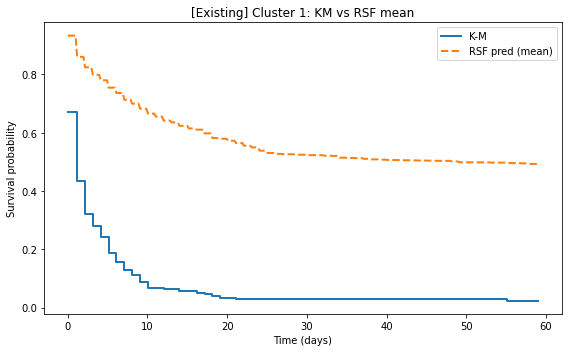

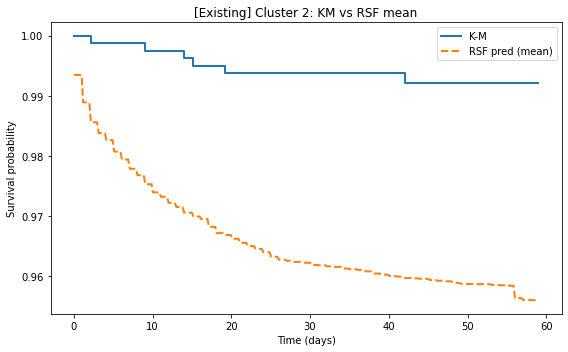

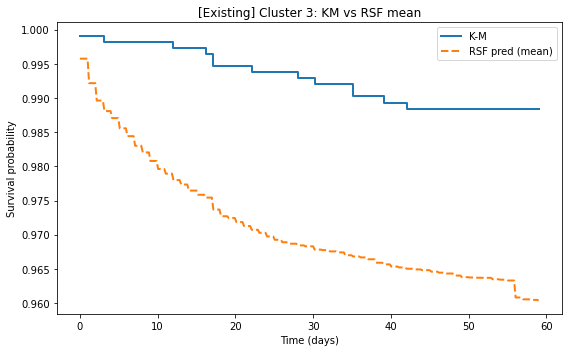

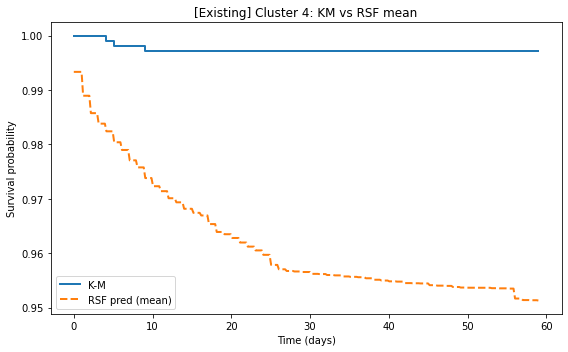

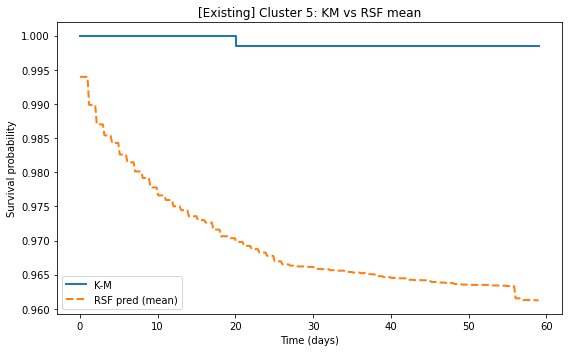

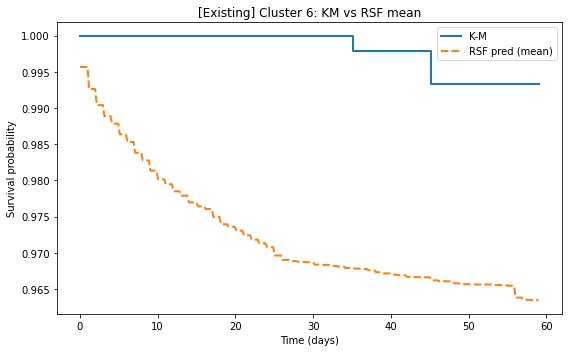

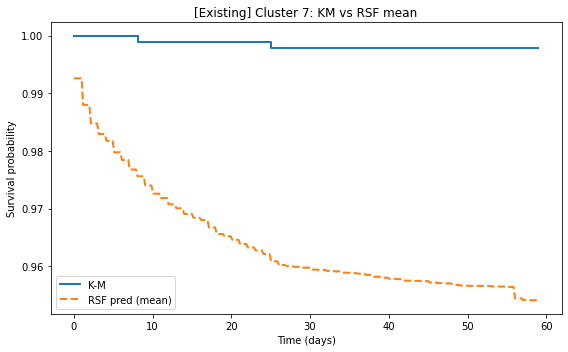

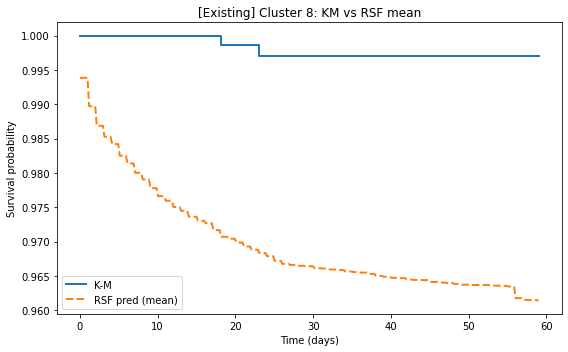

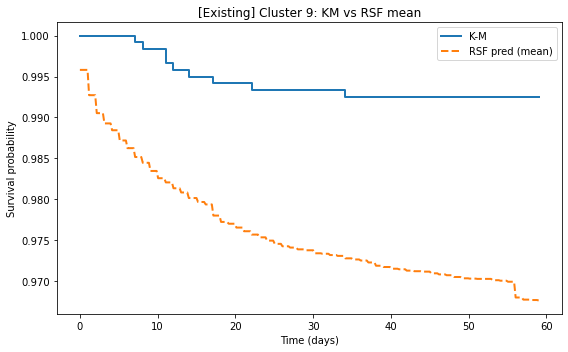

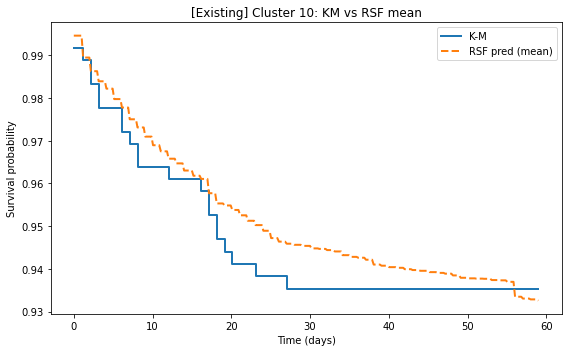

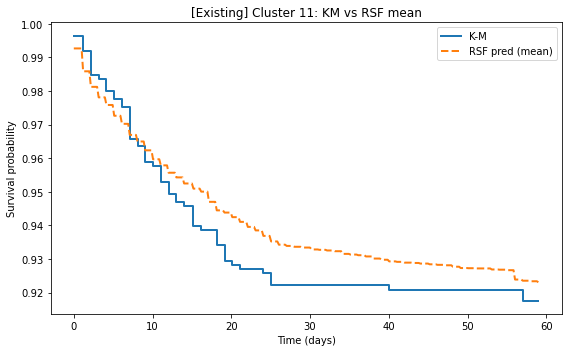

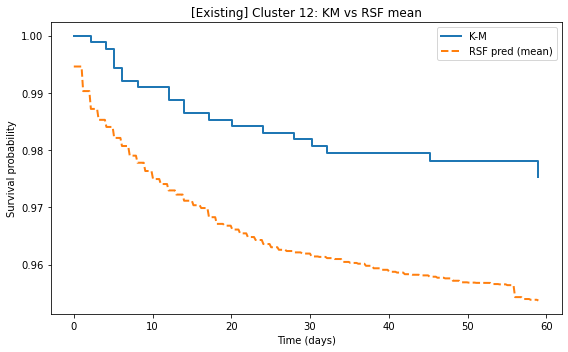

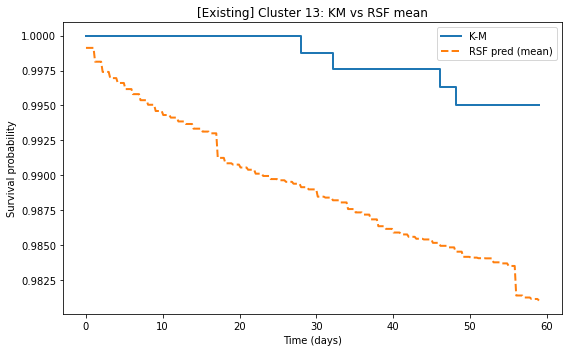

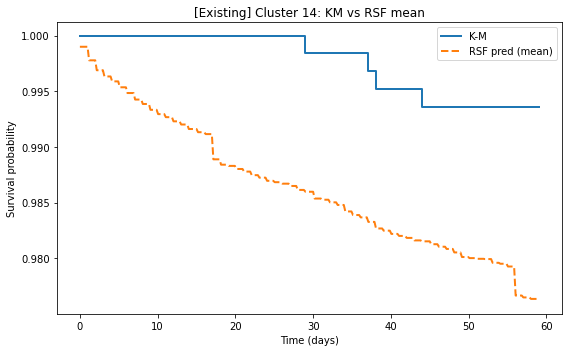

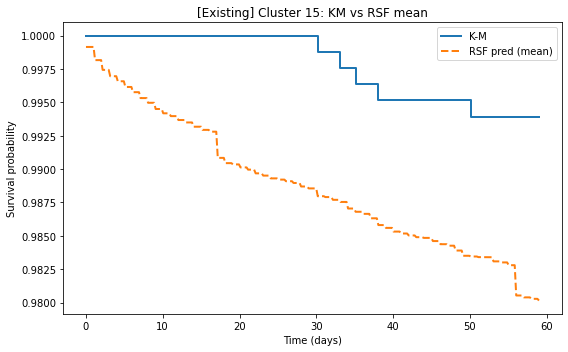

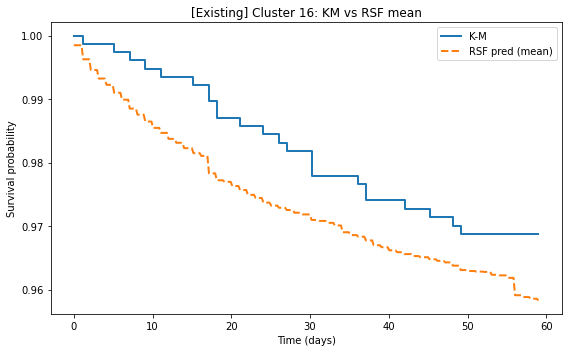

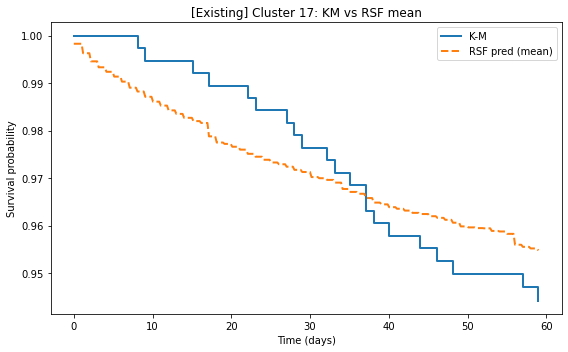

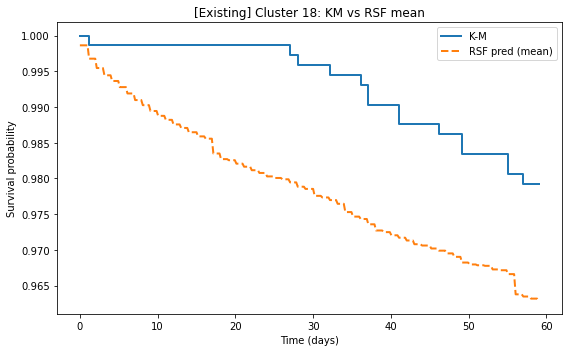

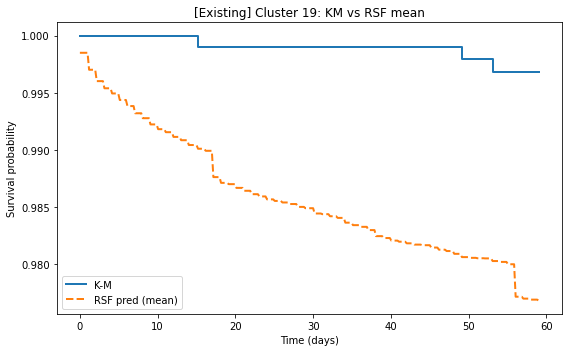

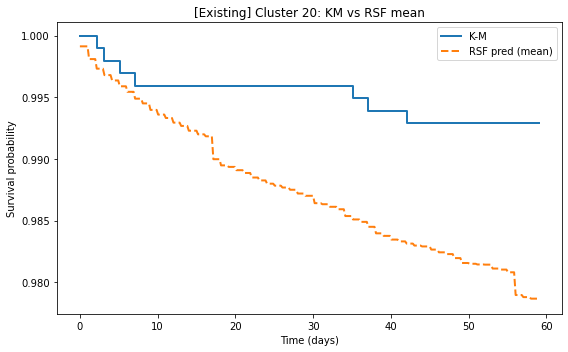

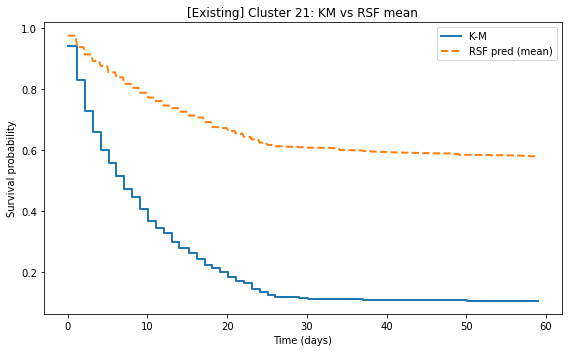

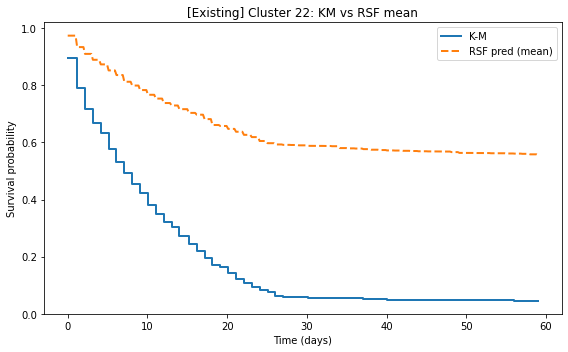

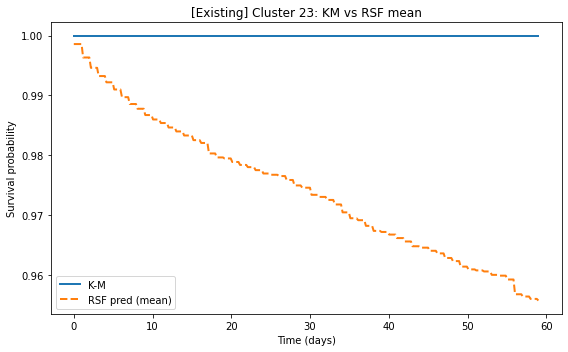

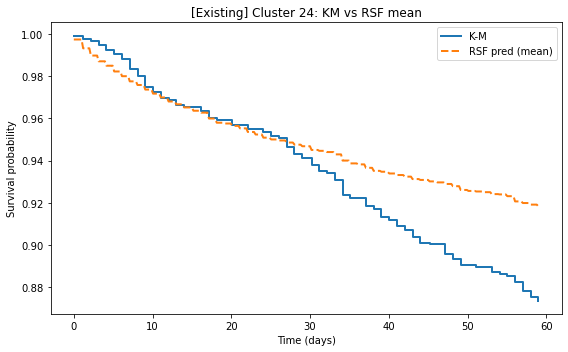

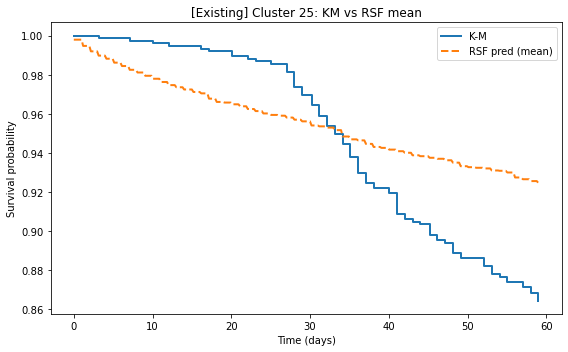

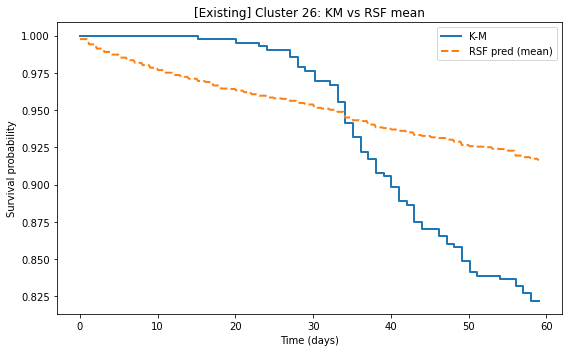

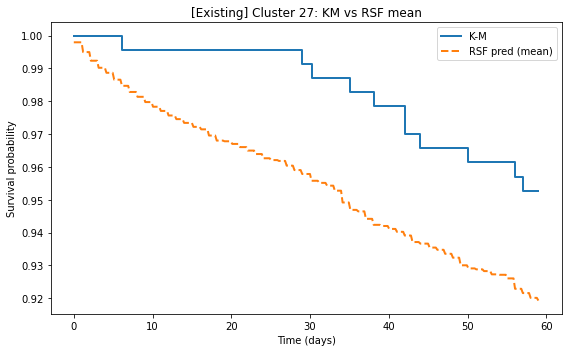

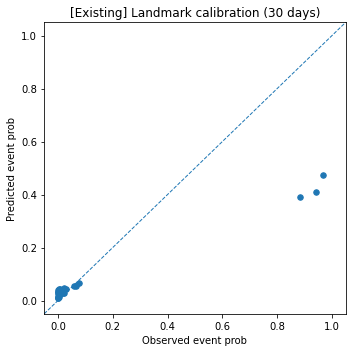

In [38]:
assert df.index.equals(X_for_rsf.index), "df와 X_for_rsf의 인덱스(idx_code)가 일치해야 합니다."
assert TIME_COL in df.columns and EVENT_COL in df.columns, "df에 생존 컬럼(TIME_COL/EVENT_COL)이 있어야 합니다."

y_time  = df[TIME_COL].astype(float)
y_event = df[EVENT_COL].astype(int)

# --- 공통 시간격자 (tau=이벤트 90% 분위수) ---
t, tau = make_time_grid(y_time.values, y_event.values, q=0.9, m=300)

# --- RSF 예측 생존함수 (개인별) ---
surv_funcs = rsf.predict_survival_function(X_for_rsf)   # list of callables
S_pred_mat = np.vstack([fn(t) for fn in surv_funcs])    # (n x len(t))
print("[4] RSF prediction ready:", S_pred_mat.shape, "| tau:", round(tau,2))

# 4-4) 실행 모드: (A) 기존 라벨 사용 vs (B) Z에서 K별로 컷팅
if USE_EXISTING_CLUSTER_LABELS:
    # A) df['Cluster_Labels'] 활용 (결과는 'existing_labels' 하위 폴더)
    outK = OUT / "existing_labels"
    outK.mkdir(parents=True, exist_ok=True)
    clusters = df["Cluster_Labels"].copy()

    # 1) 곡선 자체의 일치도
    rows = []
    for c in np.sort(pd.unique(clusters)):
        m = (clusters == c).values
        if m.sum() == 0: 
            continue
        S_km = km_curve_by_mask(y_time[m].values, y_event[m].values, t)
        S_pr = S_pred_mat[m].mean(axis=0)

        nABC = trapz(np.abs(S_km - S_pr), t) / tau
        nISE = trapz((S_km - S_pr)**2, t) / tau
        RMST_km = trapz(S_km, t)
        RMST_pr = trapz(S_pr, t)

        rows.append({"cluster": int(c), "n": int(m.sum()),
                     "nABC": nABC, "nISE": nISE,
                     "RMST_KM": RMST_km, "RMST_pred": RMST_pr, "ΔRMST": RMST_pr - RMST_km})

        plot_overlay_cluster(t, S_km, S_pr,
                             title=f"[Existing] Cluster {int(c)}: KM vs RSF mean",
                             savepath=outK / f"overlay_cluster_{int(c)}.png")

    df_curve = pd.DataFrame(rows).sort_values("cluster")
    df_curve.to_csv(outK / "curve_match_by_cluster.csv", index=False)

    # 2) 랜드마크 보정 (30/60/90일)
    landmarks = [d for d in [30,60,90] if d <= tau]
    lm_rows=[]
    for c in np.sort(pd.unique(clusters)):
        m = (clusters == c).values
        if m.sum()==0: continue
        S_km = km_curve_by_mask(y_time[m].values, y_event[m].values, t)
        S_pr = S_pred_mat[m].mean(axis=0)
        S_km_pts = np.interp(landmarks, t, S_km)
        S_pr_pts = np.interp(landmarks, t, S_pr)
        O = 1 - S_km_pts; P = 1 - S_pr_pts
        for tp, o, p in zip(landmarks, O, P):
            lm_rows.append({"cluster": int(c), "t_day": int(tp),
                            "Observed": float(o), "Predicted": float(p),
                            "Error": float(p - o), "AbsError": float(abs(p - o)),
                            "n": int(m.sum())})
    df_landmark = pd.DataFrame(lm_rows).sort_values(["cluster","t_day"])
    df_landmark.to_csv(outK / "landmark_calibration_1_2_3_months.csv", index=False)

    if len(landmarks)>0:
        plt.figure(figsize=(5,5))
        plt.axline((0,0), (1,1), linestyle="--", linewidth=1)
        plt.scatter(df_landmark["Observed"], df_landmark["Predicted"], s=30)
        plt.xlabel("Observed event prob"); plt.ylabel("Predicted event prob")
        plt.title(f"[Existing] Landmark calibration ({', '.join(map(str,landmarks))} days)")
        plt.tight_layout()
        plt.savefig(outK / "landmark_calibration_scatter.png", bbox_inches="tight")
        plt.show()

else:
    # B) K = 23,24,25,26,27 루프 (각각 하위 폴더에 저장 + 전체 합본 CSV)
    agg_curve_list, agg_landmark_list = [], []

    for K in K_LIST:
        outK = OUT / f"K{K}"
        outK.mkdir(parents=True, exist_ok=True)

        clusters = pd.Series(
            fcluster(Z, t=int(K), criterion="maxclust"),
            index=df.index, name="Cluster_Labels"
        )

        # 1) 곡선 자체의 일치도
        rows = []
        for c in np.sort(pd.unique(clusters)):
            m = (clusters == c).values
            if m.sum() == 0: 
                continue
            S_km = km_curve_by_mask(y_time[m].values, y_event[m].values, t)
            S_pr = S_pred_mat[m].mean(axis=0)

            nABC = trapz(np.abs(S_km - S_pr), t) / tau
            nISE = trapz((S_km - S_pr)**2, t) / tau
            RMST_km = trapz(S_km, t)
            RMST_pr = trapz(S_pr, t)

            rows.append({"K": int(K), "cluster": int(c), "n": int(m.sum()),
                         "nABC": nABC, "nISE": nISE,
                         "RMST_KM": RMST_km, "RMST_pred": RMST_pr, "ΔRMST": RMST_pr - RMST_km})

            plot_overlay_cluster(t, S_km, S_pr,
                                 title=f"K={K} | Cluster {int(c)}: KM vs RSF mean",
                                 savepath=outK / f"overlay_cluster_{int(c)}.png")

        df_curve_K = pd.DataFrame(rows).sort_values(["cluster"])
        df_curve_K.to_csv(outK / "curve_match_by_cluster.csv", index=False)
        agg_curve_list.append(df_curve_K)

        # 2) 랜드마크 보정 (30/60/90일)
        landmarks = [d for d in [30,60,90] if d <= tau]
        lm_rows=[]
        for c in np.sort(pd.unique(clusters)):
            m = (clusters == c).values
            if m.sum()==0: continue
            S_km = km_curve_by_mask(y_time[m].values, y_event[m].values, t)
            S_pr = S_pred_mat[m].mean(axis=0)
            S_km_pts = np.interp(landmarks, t, S_km)
            S_pr_pts = np.interp(landmarks, t, S_pr)
            O = 1 - S_km_pts; P = 1 - S_pr_pts
            for tp, o, p in zip(landmarks, O, P):
                lm_rows.append({"K": int(K), "cluster": int(c), "t_day": int(tp),
                                "Observed": float(o), "Predicted": float(p),
                                "Error": float(p - o), "AbsError": float(abs(p - o)),
                                "n": int(m.sum())})
        df_landmark_K = pd.DataFrame(lm_rows).sort_values(["cluster","t_day"])
        df_landmark_K.to_csv(outK / "landmark_calibration_1_2_3_months.csv", index=False)

        if len(landmarks)>0:
            plt.figure(figsize=(5,5))
            plt.axline((0,0), (1,1), linestyle="--", linewidth=1)
            plt.scatter(df_landmark["Observed"], df_landmark["Predicted"], s=30)
            plt.xlabel("Observed event prob")
            plt.ylabel("Predicted event prob")
            plt.xlim(0.0, 1.0)                 # <<< 고정
            plt.ylim(0.0, 1.0)                 # <<< 고정
            plt.title(f"...")
            pdf_path = Path(outK) / "landmark_calibration_scatter.pdf"
            plt.tight_layout()
            plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
            plt.show()

        agg_landmark_list.append(df_landmark_K)

    # 전체 K 합본 CSV
    df_curve_ALLK    = pd.concat(agg_curve_list, ignore_index=True)
    df_landmark_ALLK = pd.concat(agg_landmark_list, ignore_index=True)
    df_curve_ALLK.to_csv(OUT / "curve_match_by_cluster_ALLK.csv", index=False)
    df_landmark_ALLK.to_csv(OUT / "landmark_calibration_1_2_3_months_ALLK.csv", index=False)

    print("[OK] Saved per K:", K_LIST)
    print(" -", OUT / "curve_match_by_cluster_ALLK.csv")
    print(" -", OUT / "landmark_calibration_1_2_3_months_ALLK.csv")

In [44]:
def plot_cluster_individual_survivals(
    clusters_to_plot,
    t, y_time, y_event, S_pred_mat, clusters,
    title_prefix="KM vs RSF (individual)",
    max_indiv_per_cluster=150,            # 군집당 최대 개인 곡선 개수
    sample_mode="random",                  # "random" | "highest_risk" | "lowest_risk"
    show_quantile_band=True,               # 중앙값+IQR 밴드 표시
    alpha_indiv=0.08, linewidth_indiv=0.8, # 개인 곡선 스타일
    xlim=None,                             # 예: (0,60)
    savepath_pdf=None, show=True
):
    """
    S_pred_mat: (n_sample x len(t)) 개인별 예측 생존함수
    clusters:   (n_sample,) 클러스터 라벨 (pd.Series 또는 ndarray)
    """
    clusters_to_plot = list(clusters_to_plot)
    # 인덱스 정합성 체크(선택)
    assert len(S_pred_mat) == len(clusters) == len(y_time) == len(y_event), "길이가 일치해야 합니다."

    # PDF 멀티페이지 저장을 원하면 PdfPages 사용
    if savepath_pdf is not None:
        savepath_pdf = Path(savepath_pdf).with_suffix(".pdf")
        pdf = PdfPages(savepath_pdf)
    else:
        pdf = None

    for c in clusters_to_plot:
        mask = (clusters == c)
        n_c = int(mask.sum())
        if n_c == 0:
            print(f"[warn] cluster {c}: 표본 없음 -> 건너뜀")
            continue

        # 군집 내 RSF 예측 행렬
        S_c = S_pred_mat[mask]                        # (n_c x len(t))
        # 개인 선택: 너무 많으면 샘플링
        idx_local = np.arange(n_c)

        if sample_mode == "random":
            sel = np.random.choice(idx_local, size=min(max_indiv_per_cluster, n_c), replace=False)
        elif sample_mode == "highest_risk":
            # 초기 위험도 높음 = 생존함수 초반 값이 낮음 → t[?] 초반 평균으로 정렬
            # t에서 초반 10% 구간의 평균 생존값 기준
            k = max(1, int(0.1 * len(t)))
            order = np.argsort(S_c[:, :k].mean(axis=1))  # 낮을수록 위험 높음
            sel = order[:min(max_indiv_per_cluster, n_c)]
        elif sample_mode == "lowest_risk":
            k = max(1, int(0.1 * len(t)))
            order = np.argsort(S_c[:, :k].mean(axis=1))[::-1]  # 높을수록 위험 낮음
            sel = order[:min(max_indiv_per_cluster, n_c)]
        else:
            sel = np.random.choice(idx_local, size=min(max_indiv_per_cluster, n_c), replace=False)

        # KM 곡선 (군집 관측)
        S_km = km_curve_by_mask(y_time[mask], y_event[mask], t)

        # 그림
        plt.figure(figsize=(7.2, 4.8))
        # 개인 곡선(얇고 투명)
        for row in S_c[sel]:
            plt.plot(t, row, color="gray", alpha=alpha_indiv, linewidth=linewidth_indiv)

        # 중앙값 + IQR 밴드(선택)
        if show_quantile_band:
            q25 = np.percentile(S_c, 25, axis=0)
            q50 = np.percentile(S_c, 50, axis=0)
            q75 = np.percentile(S_c, 75, axis=0)
            plt.fill_between(t, q25, q75, color="tab:blue", alpha=0.15, label="RSF IQR (25–75%)")
            plt.plot(t, q50, color="tab:blue", linewidth=2, label="RSF median")

        # KM(굵은 계단선)
        plt.step(t, S_km, where="post", color="tab:red", linewidth=2.2, label="KM (observed)")

        # 축/레이블
        plt.ylim(0.0, 1.0)
        if xlim is not None:
            plt.xlim(*xlim)
        plt.xlabel("Time (days)")
        plt.ylabel("Survival probability")
        plt.title(f"{title_prefix} | Cluster {c} (n={n_c}, shown={len(sel)})")
        plt.legend(loc="best", fontsize=9, ncol=2)
        plt.tight_layout()

        # 저장/표시
        if pdf is not None:
            pdf.savefig(bbox_inches="tight")
        if show:
            plt.show()
        plt.close()

    if pdf is not None:
        pdf.close()
        print(f"[OK] saved PDF -> {savepath_pdf}")


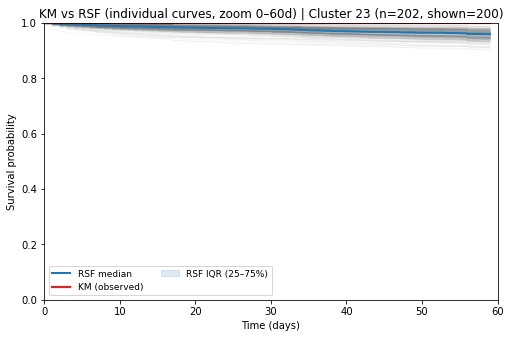

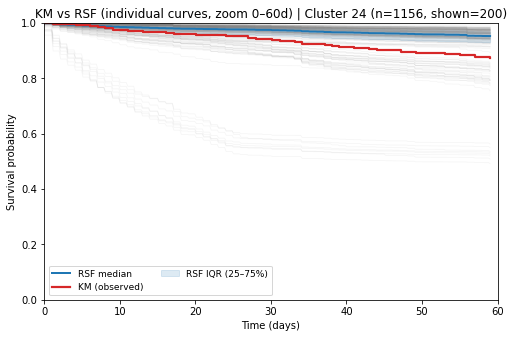

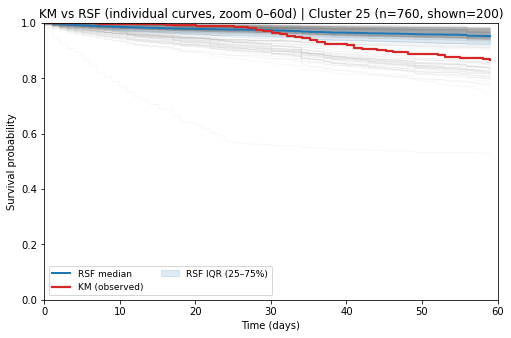

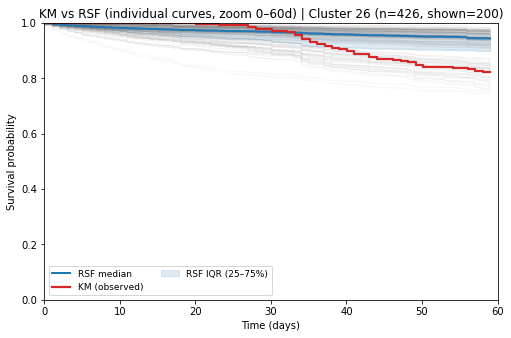

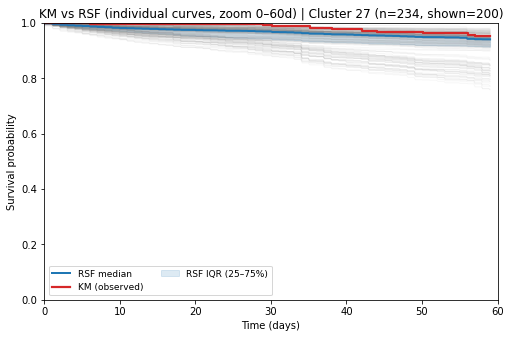

[OK] saved PDF -> /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C27/Validate_HierC_vs_RSF/overlay_individual_C23-27.pdf


In [45]:
plot_cluster_individual_survivals(
    clusters_to_plot=[23, 24, 25, 26, 27],
    t=t, y_time=y_time.values, y_event=y_event.values,
    S_pred_mat=S_pred_mat, clusters=np.asarray(clusters),
    title_prefix="KM vs RSF (individual curves, zoom 0–60d)",
    max_indiv_per_cluster=200,
    sample_mode="highest_risk",            # "highest_risk"/"lowest_risk"/"Random"
    show_quantile_band=True,
    xlim=(0, 60),
    savepath_pdf=OUT / "overlay_individual_C23-27.pdf",
    show=True
)

In [59]:
def _km_curve_and_ci(dur, evt, t, alpha=0.1):
    """KM 곡선 + Greenwood CI를 공통 t 그리드로 보간."""
    kmf = KaplanMeierFitter(alpha=alpha)
    kmf.fit(np.asarray(dur), np.asarray(evt).astype(bool))
    # 생존곡선
    S_km = kmf.survival_function_at_times(t).values
    # CI (lifelines는 timeline 기준 DF 제공 → t로 보간)
    ci_df = getattr(kmf, "confidence_interval_", None)
    if ci_df is not None:
        # 컬럼명은 버전에 따라 다를 수 있으니 자동 선택
        cols = list(ci_df.columns)
        lo_col = [c for c in cols if "lower" in c.lower()][0]
        hi_col = [c for c in cols if "upper" in c.lower()][0]
        base_x = kmf.survival_function_.index.values.astype(float)
        S_lo = np.interp(t, base_x, ci_df[lo_col].values.astype(float))
        S_hi = np.interp(t, base_x, ci_df[hi_col].values.astype(float))
    else:
        # CI 가용치 없으면 None 처리
        S_lo = None; S_hi = None
    return S_km, S_lo, S_hi

# --- 군집별: RSF 중앙값/95% 분위 밴드 + KM 95% CI (y축 0–1 고정) ---
def plot_cluster_with_CI(
    clusters_to_plot,
    t, y_time, y_event, S_pred_mat, clusters,
    title_prefix="KM vs RSF (with 90% CI)",
    show_individual=False,                # 개인 곡선 보이기 여부
    max_indiv_per_cluster=150,            # show_indiv=True일 때만 사용
    sample_mode="random",                 # "random" | "highest_risk" | "lowest_risk"
    xlim=None,                            # 예: (0,60)
    savepath_pdf=None, show=True
):
    """
    RSF 밴드: 군집 내 개인 예측의 2.5–97.5% 분위(=개인 간 분산) + 중앙값.
    *주의*: 모델 불확실성 CI가 아님(그건 부트스트랩 등 필요).
    """
    clusters_to_plot = list(clusters_to_plot)
    assert len(S_pred_mat) == len(clusters) == len(y_time) == len(y_event), "길이가 일치해야 합니다."
    pdf = PdfPages(Path(savepath_pdf).with_suffix(".pdf")) if savepath_pdf else None

    for c in clusters_to_plot:
        mask = (clusters == c)
        n_c = int(mask.sum())
        if n_c == 0:
            print(f"[warn] cluster {c}: 표본 없음 -> 건너뜀")
            continue

        # RSF 개인 예측 (군집 서브셋)
        S_c = S_pred_mat[mask]  # (n_c x len(t))

        # 선택적: 개인 곡선 샘플링
        sel = None
        if show_individual:
            idx_local = np.arange(n_c)
            if sample_mode == "random":
                sel = np.random.choice(idx_local, size=min(max_indiv_per_cluster, n_c), replace=False)
            else:
                k = max(1, int(0.1 * len(t)))  # 초기 10% 구간
                order = np.argsort(S_c[:, :k].mean(axis=1))  # 낮을수록 high-risk
                if sample_mode == "highest_risk":
                    sel = order[:min(max_indiv_per_cluster, n_c)]
                elif sample_mode == "lowest_risk":
                    sel = order[::-1][:min(max_indiv_per_cluster, n_c)]
                else:
                    sel = np.random.choice(idx_local, size=min(max_indiv_per_cluster, n_c), replace=False)

        # KM 곡선 + 95% CI
        S_km, S_km_lo, S_km_hi = _km_curve_and_ci(y_time[mask], y_event[mask], t, alpha=0.05)

#         # RSF 중앙값 + 95% 분위 밴드(2.5–97.5%)
#         q_lo, q_md, q_hi = np.percentile(S_c, [2.5, 50, 97.5], axis=0)
        # RSF 중앙값 + 95% 분위 밴드(5–95%)
        q_lo, q_md, q_hi = np.percentile(S_c, [5, 50, 95], axis=0)

        # --- 그림 ---
        plt.figure(figsize=(7.5, 5.0))

        # (옵션) 개인 곡선
        if show_individual and sel is not None:
            for row in S_c[sel]:
                plt.plot(t, row, color="gray", alpha=0.06, linewidth=0.7, zorder=1)

        # RSF 밴드(개인 이질성) + 중앙값
        plt.fill_between(t, q_lo, q_hi, color="tab:blue", alpha=0.15, label="RSF 90% band (5–95%)", zorder=2)
        plt.plot(t, q_md, color="tab:blue", linewidth=2, label="RSF median", zorder=3)

        # KM 95% CI + 계단
        if S_km_lo is not None and S_km_hi is not None:
            plt.fill_between(t, S_km_lo, S_km_hi, color="tab:red", alpha=0.15, label="K-M 90% CI", zorder=4)
        plt.step(t, S_km, where="post", color="tab:red", linewidth=2.2, label="K-M", zorder=5)

        # --- 축/레이블 (y축 0–1.0 고정) ---
        if xlim is not None:
            plt.xlim(*xlim)
        plt.ylim(0.0, 1.0)
        plt.yticks(np.linspace(0, 1, 6))
        plt.xlabel("Time (days)")
        plt.ylabel("Survival probability")
        plt.title(f"{title_prefix} | Cluster {c} (n={n_c})")
        plt.legend(loc="best", fontsize=9, ncol=2)
        plt.tight_layout()

        # 저장/표시
        if pdf is not None:
            pdf.savefig(bbox_inches="tight")
        if show:
            plt.show()
        plt.close()

    if pdf is not None:
        pdf.close()
        print(f"[OK] saved PDF -> {Path(savepath_pdf).with_suffix('.pdf')}")


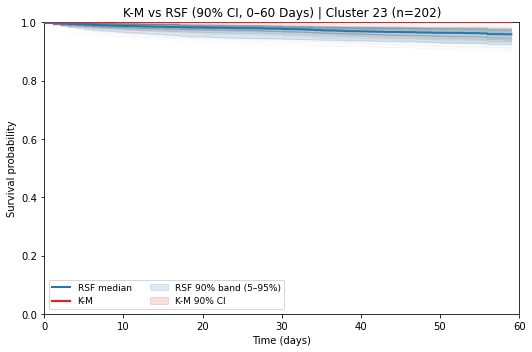

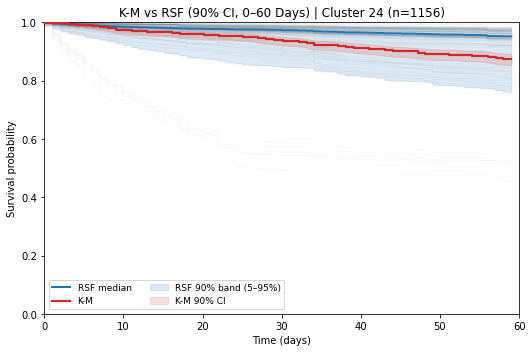

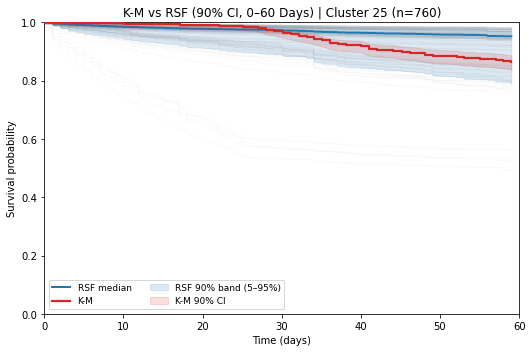

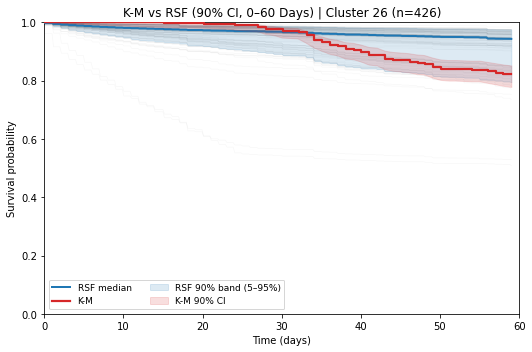

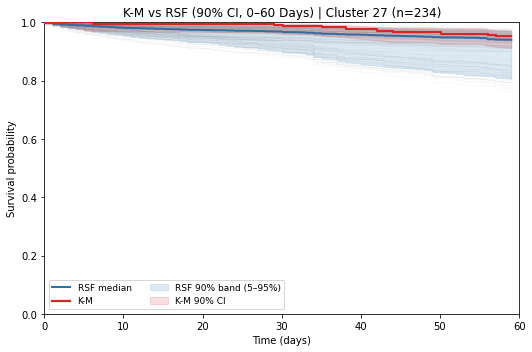

[OK] saved PDF -> /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C27/Validate_HierC_vs_RSF/overlay_CI_C23-27.pdf


In [61]:
plot_cluster_with_CI(
    clusters_to_plot=[23,24,25,26,27],
    t=t, y_time=y_time.values, y_event=y_event.values,
    S_pred_mat=S_pred_mat, clusters=np.asarray(clusters),
    title_prefix="K-M vs RSF (90% CI, 0–60 Days)",
    show_individual=True,           # Spaghetti plt
    xlim=(0,60),
    savepath_pdf=OUT / "overlay_CI_C23-27.pdf",
    show=True
)

In [68]:
def plot_cluster_survival(model, X, clusters, title, save_path,
                          figsize=(12, 7), dpi=150):
    surv_funcs = model.predict_survival_function(X)
    uniq = sorted(pd.unique(pd.Series(clusters).dropna()))
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    for cl in uniq:
        mask = (clusters == cl).values if hasattr(clusters, "values") else (np.array(clusters) == cl)
        if mask.sum() == 0:
            continue
        funcs = [surv_funcs[i] for i, keep in enumerate(mask) if keep]
        ts = np.unique(np.concatenate([fn.x for fn in funcs]))
        mat = np.vstack([fn(ts) for fn in funcs])
        mean_surv = mat.mean(axis=0)

        # ★ 추가: [0,1]로 클리핑
        mean_surv = np.clip(mean_surv, 0.0, 1.0)

        ax.step(ts, mean_surv, where="post", label=f"Cluster {cl}")

    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("Survival probability", fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)

    # ★ 추가: y축 범위 0~1 고정 (틱은 옵션)
    ax.set_ylim(0.0, 1.0)
    # ax.set_yticks(np.linspace(0, 1, 6))  # 필요하면 사용

    ncol = max(1, len(uniq))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08),
              ncol=ncol, frameon=True, fontsize=10,
              handlelength=1.8, columnspacing=1.0, borderpad=0.6, handletextpad=0.6)
    fig.subplots_adjust(bottom=0.15)

    base, _ = os.path.splitext(save_path)
    pdf_path = base + ".pdf"
    os.makedirs(os.path.dirname(pdf_path), exist_ok=True)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.show()

[INFO] Counts by cluster (C23-27):
 23     202
24    1156
25     760
26     426
27     234
Name: Cluster_Labels, dtype: int64


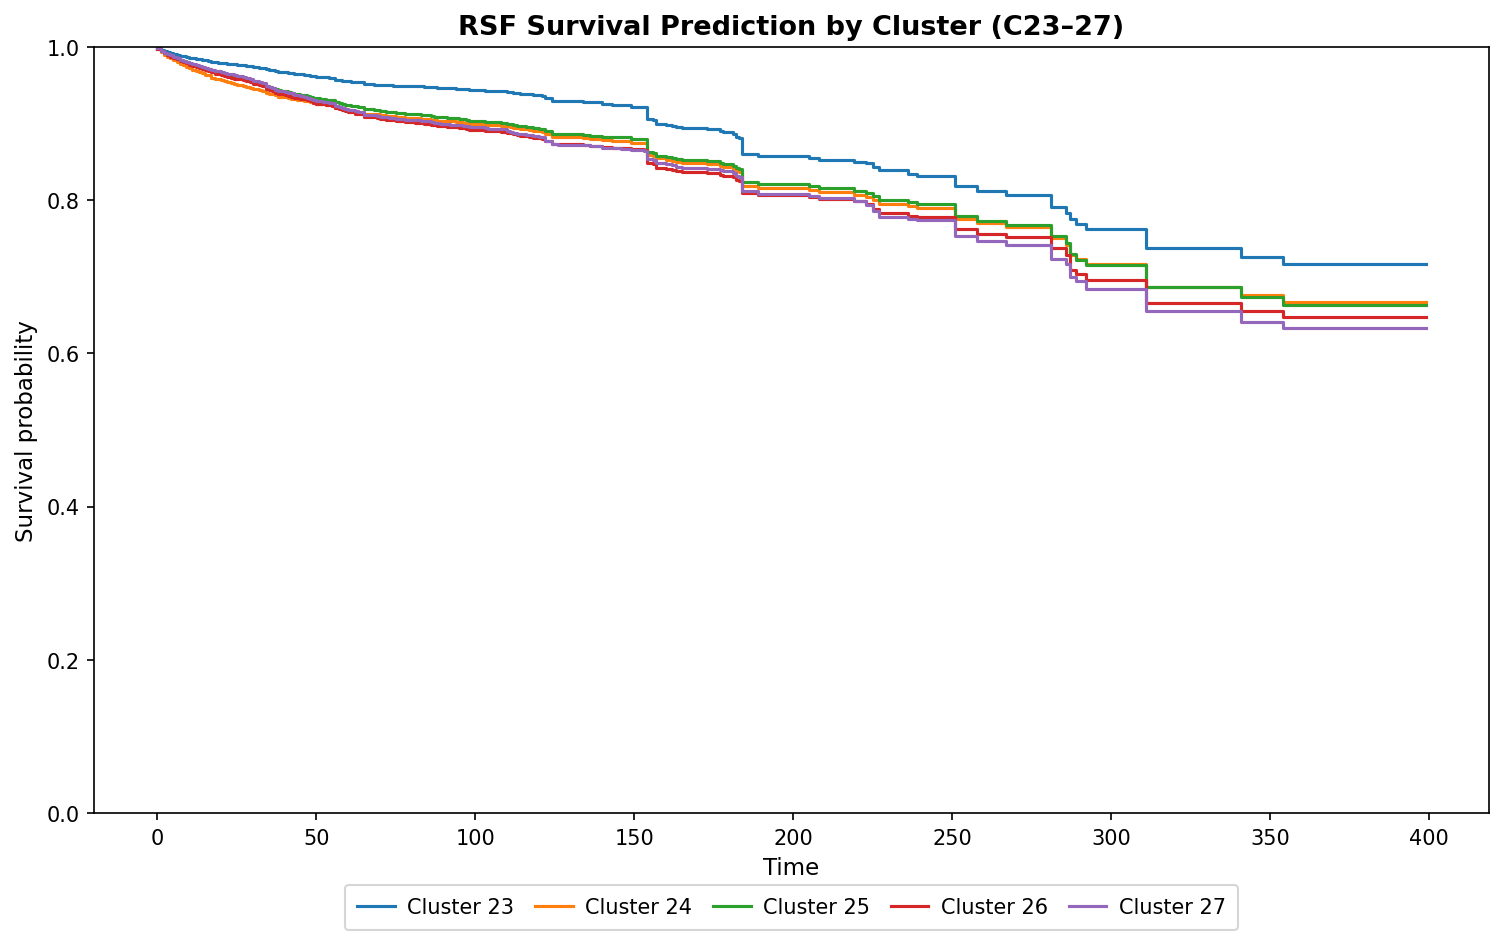

In [70]:
# ===== 23~27만 서브셋 + 플로팅 =====
ALLOW = {23, 24, 25, 26, 27}
cluster_series = pd.to_numeric(df['Cluster_Labels'], errors='coerce')
mask = cluster_series.isin(ALLOW) & cluster_series.notna()

X_sub  = X_for_rsf.loc[mask]
cl_sub = cluster_series.loc[mask].astype(int)

print("[INFO] Counts by cluster (C23-27):\n", cl_sub.value_counts().sort_index())

(fig_dir := OUT / "figs").mkdir(parents=True, exist_ok=True)
save_path = str(fig_dir / "survival_by_cluster_23to27_test.pdf")

plot_cluster_survival(
    rsf,
    X_sub,
    cl_sub,
    "RSF Survival Prediction by Cluster (C23–27)",
    save_path
)